In [1]:
import os
import itertools
import importlib
import time
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
import datetime as dt
from cycler import cycler
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
import matplotlib.patches as mpatches
from pdb import set_trace

from gfatpy.lidar.preprocessing import preprocess
from gfatpy.lidar.preprocessing.lidar_preprocessing import apply_dead_time_correction
from gfatpy.lidar.preprocessing.lidar_preprocessing_tools import preprocessing_photoncounting_signal
from gfatpy.lidar.preprocessing.gluing_proportional import gluing
%matplotlib inline

In [3]:
def plot_hist_num_measurements(year=None):
    """

    :return:
    """

    if year is not None:
        year_ini = year
        year_end = year
    else:
        year_ini = 2018
        year_end = 2020

    date_ini = dt.datetime(year_ini, 1, 1)
    date_end = dt.datetime(year_end, 12, 31)
    dates_ls = pd.date_range(date_ini, date_end)
    num_meas = np.zeros(len(dates_ls))
    for i, idate in enumerate(dates_ls):
        print(idate)
        i_fn = os.path.join(".", "dead_time",
                            "dead_time_%s_532p_ngt_scc_1.nc" % idate.strftime("%Y%m%d"))
        if os.path.isfile(i_fn):
            try:
                ds = xr.open_dataset(i_fn)
                # corrijo un fallo de seleccion de medidas
                times_a = ds.times.values
                sun = solar.SUN(times_a, -3.61, 37.16, elev=680)
                csza = sun.get_csza()
                idx_ilu = np.where(csza < -0.01)
                times_ilu = times_a[idx_ilu]
                ds = ds.sel(times=times_ilu)
                num_meas[i] = ds.dims["times"]
                ds.close()
            except:
                print("%s: no data" % idate)
    df = pd.DataFrame.from_dict({"times": dates_ls, "num": num_meas})
    plt.close('all')
    f, ax = plt.subplots(figsize=(8.5, 3.75), constrained_layout=True)
    ax.bar(df.times, df.num)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.axes.set_xlim('2019-01-01', '2019-12-31')
    ax.axes.set_xlabel('Date')
    ax.axes.set_ylabel('num. of measurements')
    if year is not None:
        ax.set_title('MULHACEN: measurements along %s' % year)
        plt.savefig("lidar_measurements_%s.png" % (year,), dpi=300)
    else:
        ax.set_title('MULHACEN: measurements along %s-%s' % (year_ini, year_end))
        plt.savefig("lidar_measurements_%s_%s.png" % (year_ini, year_end), dpi=300)

    return df


def plot_J_lines(fn=None, ds=None):
    """

    """
    if fn is not None:
        ds = xr.open_dataset(fn)
    dx = ds.isel(times=10)

    colors = mpl.cm.jet(np.linspace(0, 1, ds.dims["steps"]))
    custom_cycler = cycler(color=colors)
    cm = mpl.cm.get_cmap('jet', ds.dims["steps"])

    plt.close('all')
    f, ax = plt.subplots(constrained_layout=True)
    ax.set_prop_cycle(custom_cycler)
    lines = [np.column_stack([dx.tau.values, np.log(dx.J).values[:, i]]) for i in range(dx.dims["steps"])]
    lc = LineCollection(lines, cmap=cm, lw=3)
    lc.set_array(dx.range_glue_extended_thick[0, :].values)
    ax.add_collection(lc)
    axcb = f.colorbar(lc, ax=ax)

    x_label = r"dead time [ns]"
    y_label = r"residual, log(J)"
    hue_label = r"region thickness [m]"
    plot_title = r"J vs $\tau$ vs linear response region thickness"

    ax.axes.set_ylim(np.log(dx.J).min(skipna=True), np.log(dx.J).max(skipna=True))
    ax.axes.set_xlim(dx.tau.min(skipna=True) - 0.1, dx.tau.max(skipna=True) + 0.1)

    label_size = 12
    tick_label_size = 11

    ax.tick_params(axis="x", labelsize=tick_label_size)
    ax.tick_params(axis="y", labelsize=tick_label_size)
    ax.set_xlabel(x_label, fontsize=label_size)
    ax.set_ylabel(y_label, fontsize=label_size)
    ax.set_title(plot_title)
    axcb.set_label(hue_label, fontsize=label_size)
    axcb.ax.tick_params(labelsize=tick_label_size)

    plt.savefig("J_lines.png", dpi=300)


def plot_J_contour(fn=None, ds=None):
    """

    """
    if fn is not None:
        ds = xr.open_dataset(fn)
    dx = ds.isel(times=10)

    plt.close('all')
    f, ax = plt.subplots(constrained_layout=True)
    cs = ax.contourf(np.tile(dx.tau, [dx.dims["steps"], 1]).T,
                     dx.range_glue_extended_thick,
                     np.log(dx.J), cmap="jet")
    axcb = f.colorbar(cs)

    x_label = r"dead time [ns]"
    y_label = r"region thickness [m]"
    hue_label = r"residual, log(J)"
    plot_title = r"J vs $\tau$ vs linear response region thickness"

    ax.axes.set_xlim(dx.tau.min(skipna=True) - 0.1, dx.tau.max(skipna=True) + 0.1)

    label_size = 12
    tick_label_size = 11

    ax.tick_params(axis="x", labelsize=tick_label_size)
    ax.tick_params(axis="y", labelsize=tick_label_size)
    ax.set_xlabel(x_label, fontsize=label_size)
    ax.set_ylabel(y_label, fontsize=label_size)
    ax.set_title(plot_title)
    axcb.set_label(hue_label, fontsize=label_size)
    axcb.ax.tick_params(labelsize=tick_label_size)

    plt.savefig("J_contour.png", dpi=300)


def plot_scatter_dead_time(fn=None, ds=None):
    """
    SCATTER ESTIMATED DEAD TIME AS DEPENDENT ON REGION THICKNESS
    """

    if fn is not None:
        ds = xr.open_dataset(fn)

    date_ini = ds.times[0].values
    date_end = ds.times[-1].values
    date_ini = utils.numpy_to_datetime(date_ini)
    date_end = utils.numpy_to_datetime(date_end)
    delta_t = (date_end - date_ini).seconds / 3600
    plot_title = "%s: %.1f hours. %i profiles" % (date_ini.strftime("%Y%m%d"),
                                                  delta_t, ds.dims["times"])
    x_label = r"dead time [ns]"
    y_label = r"region thickness [m]"
    hue_label = r"r Pearson (Glued - Photon-counting)"

    label_size = 12
    tick_label_size = 11

    # height limits
    #h_limits = np.arange(0, 7500, 500)
    color_map = "jet"
    hue_limits = (0.95, 1)
    hue_step = 0.005
    num_colors = round((hue_limits[1] - hue_limits[0])/hue_step)

    f, ax = plt.subplots(constrained_layout=True)
    # plot
    for i in range(ds.dims["times"]):
        cs = ds.isel(times=i).plot.scatter(ax=ax, x="tau_min", y="range_glue_extended_thick",
                hue="rvalue_gl_pc", cmap=mpl.cm.get_cmap(color_map, num_colors),
                vmin=hue_limits[0], vmax=hue_limits[1],
                extend='min', add_guide=False)
    ax.tick_params(axis="x", labelsize=tick_label_size)
    ax.tick_params(axis="y", labelsize=tick_label_size)
    ax.set_xlabel(x_label, fontsize=label_size)
    ax.set_ylabel(y_label, fontsize=label_size)
    ax.set_title(plot_title)
    # colorbar
    cb = plt.colorbar(cs)
    #cb.ax.locator_params(nbins=num_colors)
    #cb.ax.set_title('hola')
    cb.set_label(hue_label, fontsize=label_size)
    cb.ax.tick_params(labelsize=tick_label_size)

    plt.savefig("dead_time_distribution_region_thickness.png", dpi=300)

    ds.close()


def plot_dead_time_hist(fn=None, ds=None, label=None):
    """

    """
    if fn is not None:
        ds = xr.open_dataset(fn)

    date_ini = ds.times[0].values
    date_end = ds.times[-1].values
    date_ini = utils.numpy_to_datetime(date_ini)
    date_end = utils.numpy_to_datetime(date_end)
    delta_t = (date_end - date_ini).seconds / 3600
    plot_title = "%s: %.1f hours. %i profiles" % (date_ini.strftime("%Y%m%d"),
                                                  delta_t, ds.dims["times"])
    label_size = 12
    tick_label_size = 11

    f, ax = plt.subplots(constrained_layout=True)
    ds.tau_best_avg.plot.hist(ax=ax, bins=ds.tau, color='royalblue')
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_minor_locator(MultipleLocator(0.5))
    ax.axes.set_xlabel("Dead Time [ns]", fontsize=label_size)
    ax.axes.set_ylabel("Counts", fontsize=label_size)
    ax.set_title(plot_title)#, fontsize=16)
    ax.tick_params(axis="x", labelsize=tick_label_size)
    ax.tick_params(axis="y", labelsize=tick_label_size)
    #l1 = mpatches.Patch(color='royalblue') #, label="day")
    #l1_t = mpatches.Patch(color='w', label="\n".join((r"$\mu = %.1f$" % (ds_day.tau_min.mean(), ), r"$\sigma = %.1f$" % (ds_day.tau_min.std(),))))
    l1_t = mpatches.Patch(color='royalblue', label="\n".join((r"$\mu = %.1f$" %
                    (ds.tau_best_avg.mean(), ), r"$\sigma = %.1f$" % (ds.tau_best_avg.std(),))))
    ax.legend(handles=[l1_t], fontsize=label_size)


    if label is not None:
        plt_fn = "dead_time_hist_%s.png" % label
    else:
        plt_fn = "dead_time_hist.png"
    plt.savefig(plt_fn, dpi=300)

    ds.close()


def plot_dead_time_ts(year=None, df=None):
    """
    """

    if df is None:
        if year is not None:
            year_ini = year
            year_end = year
        else:
            year_ini = 2018
            year_end = 2020

        date_ini = dt.datetime(year_ini, 1, 1)
        date_end = dt.datetime(year_end, 12, 31)
        dates_ls = pd.date_range(date_ini, date_end)
        tau_532p_avg = np.zeros(len(dates_ls))*np.nan
        tau_532p_std = np.zeros(len(dates_ls))*np.nan
        tau_532c_avg = np.zeros(len(dates_ls))*np.nan
        tau_532c_std = np.zeros(len(dates_ls))*np.nan
        tau_355_avg = np.zeros(len(dates_ls))*np.nan
        tau_355_std = np.zeros(len(dates_ls))*np.nan
        for i, idate in enumerate(dates_ls):
            print(idate)
            i_fn = os.path.join(".", "dead_time", "dead_time_%s_532p_ngt_scc_1.nc" % idate.strftime("%Y%m%d"))
            #if "20191010" in i_fn:
            #    pdb.set_trace()
            if os.path.isfile(i_fn):
                try:
                    ds = xr.open_dataset(i_fn)
                    tau_532p_avg[i] = ds.tau_best_avg.mean(skipna=True)
                    tau_532p_std[i] = ds.tau_best_avg.std(skipna=True)
                    ds.close()
                except:
                    print("%s: no data for 532p" % idate)
            i_fn = os.path.join(".", "dead_time", "dead_time_%s_532c_ngt_scc_1.nc" % idate.strftime("%Y%m%d"))
            if os.path.isfile(i_fn):
                try:
                    ds = xr.open_dataset(i_fn)
                    tau_532c_avg[i] = ds.tau_best_avg.mean(skipna=True)
                    tau_532c_std[i] = ds.tau_best_avg.std(skipna=True)
                    ds.close()
                except:
                    print("%s: no data for 532c" % idate)
            i_fn = os.path.join(".", "dead_time", "dead_time_%s_355_ngt_scc_1.nc" % idate.strftime("%Y%m%d"))
            if os.path.isfile(i_fn):
                try:
                    ds = xr.open_dataset(i_fn)
                    tau_355_avg[i] = ds.tau_best_avg.mean(skipna=True)
                    tau_355_std[i] = ds.tau_best_avg.std(skipna=True)
                    ds.close()
                except:
                    print("%s: no data for 355" % idate)

        df = pd.DataFrame.from_dict({"times": dates_ls,
                                     "tau_532p_avg": tau_532p_avg, "tau_532p_std": tau_532p_std,
                                     "tau_532c_avg": tau_532c_avg, "tau_532c_std": tau_532c_std,
                                     "tau_355_avg": tau_355_avg, "tau_355_std": tau_355_std})
    # plot
    plt.close('all')
    f, ax = plt.subplots(figsize=(8.5, 3.75), constrained_layout=True)
    ax.plot(df.times, df.tau_532p_avg, lw=0, label="532p", color='b', marker='o')
    #ax.fill_between(df.times, df.tau_532p_avg + df.tau_532p_std, df.tau_532p_avg - df.tau_532p_std, facecolor='b', alpha=0.5)
    ax.plot(df.times, df.tau_532c_avg, lw=0, label="532c", color='r', marker='o')
    #ax.fill_between(df.times, df.tau_532c_avg + df.tau_532c_std, df.tau_532c_avg - df.tau_532c_std, facecolor='r', alpha=0.5)
    ax.plot(df.times, df.tau_355_avg, lw=0, label="355", color='k', marker='o')
    #ax.fill_between(df.times, df.tau_355_avg + df.tau_355_std, df.tau_355_avg - df.tau_355_std, facecolor='k', alpha=0.5)
    label_size = 12
    tick_label_size = 11

    ax.legend(fontsize=label_size)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.axes.set_xlim('2019-01-01', '2019-12-31')
    ax.tick_params(axis="x", labelsize=tick_label_size)
    ax.tick_params(axis="y", labelsize=tick_label_size)
    ax.set_xlabel("Date", fontsize=label_size)
    ax.set_ylabel("dead time [ns]", fontsize=label_size)
    if year is not None:
        ax.set_title('MULHACEN: dead time estimates. Year %s' % year)
        plt.savefig("dead_time_ts_%s.png" % (year,), dpi=300)
    else:
        ax.set_title('MULHACEN: dead time estimates. Period %s-%s' % (year_ini, year_end))
        plt.savefig("dead_time_ts_%s_%s.png" % (year_ini, year_end), dpi=300)

    return df

In [2]:
data = r'C:\Users\Usuario\Documents\gitlab\gfatpy\tests\datos\MULHACEN\1a\2022\08\08\mhc_1a_Prs_rs_xf_20220808_1131.nc'

lidar = preprocess(data, apply_dt=False, save_bg=True, save_dc=True)

In [3]:
lidar

<xarray.Dataset>
Dimensions:              (time: 1028, range: 2666, channel: 10)
Coordinates:
  * time                 (time) datetime64[ns] 2022-08-07T23:59:03 ... 2022-0...
  * range                (range) float32 7.5 15.0 22.5 ... 1.999e+04 2e+04
  * channel              (channel) object '532xpa' '532xpp' ... '408xtp'
Data variables: (12/43)
    lat                  float32 ...
    lon                  float32 ...
    altitude             float32 ...
    zenith_angle         (time) float32 dask.array<chunksize=(1028,), meta=np.ndarray>
    azimuth_angle        (time) float32 dask.array<chunksize=(1028,), meta=np.ndarray>
    time_resol           float32 ...
    ...                   ...
    bg_355xta            (time) float64 dask.array<chunksize=(1028,), meta=np.ndarray>
    bg_355xtp            (time) float64 dask.array<chunksize=(1028,), meta=np.ndarray>
    bg_1064xta           (time) float64 dask.array<chunksize=(1028,), meta=np.ndarray>
    bg_530xtp            (time) float64 dask.array<chunksize=(1028,), meta=np.ndarray>
    bg_354xtp            (time) float64 dask.array<chunksize=(1028,), meta=np.ndarray>
    bg_408xtp            (time) float64 dask.array<chunksize=(1028,), meta=np.ndarray>
Attributes: (12/87)
    system:                          MULHACEN
    manufacturers:                   Raymetrics
    overlap_is_corrected:            false
    overlap_function:                false
    site_location:                   Granada, Spain
    instrument_id:                   MULHACEN
    ...                              ...
    telescope1_diameter:             400
    BCK_MIN_ALT:                     75000
    BCK_MAX_ALT:                     105000
    dc_corrected:                    True
    bg_corrected:                    True
    bz_corrected:                    True

In [5]:
channel_an = '532xpa'
selected_range = (0,6000.)
lidar[f'signal_{channel_an}'].sel(range=slice(0,6000.)).values

array([[-0.11887394,  0.23849782,  0.23766683, ...,  0.01456417,
         0.00461749,  0.00906166],
       [-0.13143269,  0.2371519 ,  0.22303146, ...,  0.0078195 ,
         0.0086708 ,  0.00667719],
       [-0.12570768,  0.24246158,  0.23498587, ...,  0.00939173,
         0.0096198 ,  0.00824942],
       ...,
       [ 0.09404973,  0.58971809,  0.58992614, ...,  0.01858882,
         0.01860947,  0.01080178],
       [ 0.11584166,  0.60528015,  0.59697426, ...,  0.01919964,
         0.01693624,  0.01660393],
       [ 0.10835579,  0.58346675,  0.5911497 , ...,  0.01981238,
         0.01671833,  0.01970862]])

In [7]:
def estimate_dead_time(date_str, channel, time_range=None,
                       gluing_type="scc", expand_bins=True):
    """
    channel (str): dddss
    """
    
    print("Estimate Dead Time for %s. channel=%s" % (date_str, channel))
    # get raw data
#         an, pc, an_dc, ranges, times, bg_range, rs_range, idx_bg_range, idx_rs_range, \
#         rs_ds, dc_ds, an_ch, pc_ch, wv, pol = lidar_read.get_prepared_data(
#             date_str, channel, don, 15000, time_range=time_range)

    # get raw data    
    lidar = preprocess(data, apply_dt=False, save_bg=True, save_dc=True, apply_bz=False)    
    channel_an = channel + 'a'
    channel_pc = channel + 'p'

    if not channel_an in lidar.channel:
        raise ValueError('channel not found.')

    if not channel_pc in lidar.channel:
        raise ValueError('channel not found.')

    #select signal
    an = lidar[f'signal_{channel_an}'].sel(range=slice(0,6000.))
    pc = lidar[f'signal_{channel_pc}'].sel(range=slice(0,6000.))

    #select background
    bg_an = lidar[f'bg_{channel_an}'].values
    bg_pc = lidar[f'bg_{channel_pc}'].values

    #select dark current
    dc_an = lidar[f'dc_{channel_an}'].sel(range=slice(0,6000.))

    #select range
    ranges = lidar[f'signal_{channel_pc}'].sel(range=slice(0,6000.))

    
    # analog channel additional info        
    adc_range = 1000*lidar.adc_range.sel(channel=channel_an)
    adc_bits = lidar.adc_bits.sel(channel=channel_an)
    n_res = 1
    
    set_trace()
    
    # taus [in nanoseconds]
    tau_step = 0.1  # 0.05
    tau = np.arange(0, 10+tau_step, tau_step)

    # expand glue region
    bin_step = 10
    bin_max = 150
    exp_glue = np.arange(0, bin_max + bin_step, bin_step)*7.5

    # dimensions
    n_t = len(times)
    n_ranges = len(ranges)
    n_tau = len(tau)
    n_steps = len(exp_glue)

    # Define variables for output
    tau_best_avg = np.zeros(n_t)
    tau_best_std = np.zeros(n_t)
    thickness_best_avg = np.zeros(n_t)
    thickness_best_std = np.zeros(n_t)
    tau_min = np.zeros((n_t, n_steps))*np.nan
    r_min = np.zeros((n_t, n_steps))*np.nan
    r_min2 = np.zeros((n_t, n_steps))*np.nan
    thickness_minJ = np.zeros((n_t, n_steps))*np.nan
    J = np.zeros((n_t, n_tau, n_steps))*np.nan
    range_glue_first_min = np.zeros((n_t, n_tau))*np.nan
    range_glue_first_max = np.zeros((n_t, n_tau))*np.nan
    range_glue_min = np.zeros((n_t, n_tau))*np.nan
    range_glue_max = np.zeros((n_t, n_tau))*np.nan
    an_pp = np.zeros((n_t, n_ranges))*np.nan
    pc_pp = np.zeros((n_t, n_ranges, n_tau))*np.nan
    gl_pp = np.zeros((n_t, n_ranges, n_tau))*np.nan
    rvalue = np.zeros((n_t, n_tau, n_steps))*np.nan
    rvalue2 = np.zeros((n_t, n_tau, n_steps))*np.nan
    range_glue_ext_min = np.zeros((n_t, n_tau, n_steps))*np.nan
    range_glue_ext_max = np.zeros((n_t, n_tau, n_steps))*np.nan
    range_glue_ext_thick = np.zeros((n_t, n_tau, n_steps))*np.nan

    bz_pc = 0 
    set_trace()
    # Loop over signals
    
    for j, tau_ in enumerate(tau):
        # Dead time correction photoncounting
        pc_ij = apply_dead_time_correction(pc, tau_)
        pc_pp[i, :, j] = pc_ij
        
        #Gluing
        gl_pp, error, gluing_height = lidar.gluing(an, pc, ranges)    
    
        # Cost Function: para cada perfil uso el mismo rango para todos los taus
        min_glue_i = gluing_height-250.
        max_glue_i =  gluing_height+250.
        
        for k in range(n_steps):
            # anchura de region
            min_glue = min_glue_i
            max_glue = max_glue_i
            idx_glue = np.logical_and(ranges >= min_glue, ranges <= max_glue)
            # rangos
            range_glue_ext_min[i, j, k] = min_glue
            range_glue_ext_max[i, j, k] = max_glue
            range_glue_ext_thick[i, j, k] = max_glue - min_glue

            # correlación AN vs PC en la region
            rvalue[i, j, k] = np.corrcoef(an_pp[i, idx_glue], pc_pp[i, idx_glue, j])[0, 1]
            rvalue2[i, j, k] = np.corrcoef(gl_pp[i, idx_glue, j], pc_pp[i, idx_glue, j])[0, 1]
            if np.logical_and(~np.isnan(rvalue2[i, j, k]), rvalue2[i, j, k] >= 0.9):
                if rvalue[i, j, k] >= 0.9:
                    J[i, j, k] = utils.residuals(pc_pp[i, idx_glue, j], gl_pp[i, idx_glue, j])
    
        set_trace()
        # Tau that Minimizes Cost Function and associated rvalues for an_pc and gl_pc
        for k in range(n_steps):
            jj = J[i, :, k]
            rr = rvalue[i, :, k]
            rr2 = rvalue2[i, :, k]
            th = range_glue_ext_thick[i, :, k]
            try:
                if ~(np.isnan(jj).any()):
                    idx_Jmin = np.nanargmin(jj)
                    tau_min[i, k] = tau[idx_Jmin]
                    r_min[i, k] = rr[idx_Jmin]
                    r_min2[i, k] = rr2[idx_Jmin]
                    thickness_minJ[i, k] = th[idx_Jmin]
            except Exception as e:
                print(str(e))
                print("Tau min not estimated for profile %i-th, step %i-th" % (i, k))

        # CRITERIUM TO ESTIMATE DEAD TIME
        # for every thickness, a best tau is estimated above.
        # So, we have a list of best taus. from them, we derive the best
        # of the best, considering the correlation index gl_pc
        try:
            idx_best_tau = r_min2[i, :] >= (np.nanmax(r_min2[i, :]) - np.nanstd(r_min2[i, :]))
            tau_best_avg[i] = np.nanmean(tau_min[i, idx_best_tau])
            tau_best_std[i] = np.nanstd(tau_min[i, idx_best_tau])
            thickness_best_avg[i] = np.nanmean(thickness_minJ[i, idx_best_tau])
            thickness_best_std[i] = np.nanstd(thickness_minJ[i, idx_best_tau])
        except Exception as e:
            print(str(e))
            print("Best Tau not estimated for profile %i-th" % i)

    # save results in netcdf
    ds = xr.Dataset({"J":                       (["times", "tau", "steps"], J),
                     "tau_min":                 (["times", "steps"], tau_min),
                     "tau_best_avg":            (["times"], tau_best_avg),
                     "tau_best_std":            (["times"], tau_best_std),
                     "thickness_best_avg":            (["times"], thickness_best_avg),
                     "thickness_best_std":            (["times"], thickness_best_std),
                     "range_glue_extended_min": (["times", "tau", "steps"], range_glue_ext_min),
                     "range_glue_extended_max": (["times", "tau", "steps"], range_glue_ext_max),
                     "range_glue_extended_thick": (["times", "tau", "steps"], range_glue_ext_thick),
                     "rvalue_an_pc": (["times", "tau", "steps"], rvalue),
                     "rvalue_gl_pc": (["times", "tau", "steps"], rvalue2)},
                    coords={"times": times, "tau": tau, "steps": exp_glue, "ranges": ranges})
    fn = os.path.join(config.dead_time_dn, "dead_time_%s_%s_%s_%s_%i.nc"
                      % (date_str, channel, don_str, gluing_type, expand_bins))
    ds.to_netcdf(fn)
    time_elapsed = time.time() - t_start
    print("%.1f s of time elapsed for %s:%s (%i profiles). channel=%s" % (
        time_elapsed, date_str, don_str, ds.dims["times"], channel))

    return ds, fn

In [ ]:
estimate_dead_time('20220808', '532xp')

Estimate Dead Time for 20220808. channel=532xp


In [ ]:
glob.glob('*.nc')

In [ ]:
def run_period(date_ini, date_end, expand_step=True):
    """
    Perform Dead Time Estimation for a given period

    Params:
    ------
    date_ini (str, yyyymmdd): 
    date_end (str, yyyymmdd): 
    expand_step (bool):
        estimate for several thicknesses of gluing region
    """

    channel = ['532p', '532c', '355']
    don = [1, 2]
    dates_str = [x.strftime("%Y%m%d") for x in pd.date_range(date_ini, date_end)]
    inp = [x for x in itertools.product(dates_str, channel, don,
                                        [None], ["scc"], [expand_step])]
    for x in inp:
        print(x)
        estimate_dead_time(*x)

In [76]:
lidar = preprocess(data, apply_dt=False)

In [6]:
lidar

<xarray.Dataset>
Dimensions:              (time: 1028, range: 2666, channel: 10)
Coordinates:
  * time                 (time) datetime64[ns] 2022-08-07T23:59:03 ... 2022-0...
  * range                (range) float32 7.5 15.0 22.5 ... 1.999e+04 2e+04
  * channel              (channel) object '532xpa' '532xpp' ... '408xtp'
Data variables: (12/29)
    lat                  float32 ...
    lon                  float32 ...
    altitude             float32 ...
    zenith_angle         (time) float32 dask.array<chunksize=(1028,), meta=np.ndarray>
    azimuth_angle        (time) float32 dask.array<chunksize=(1028,), meta=np.ndarray>
    time_resol           float32 ...
    ...                   ...
    signal_355xta        (time, range) float64 dask.array<chunksize=(1028, 2666), meta=np.ndarray>
    signal_355xtp        (time, range) float64 dask.array<chunksize=(1028, 2666), meta=np.ndarray>
    signal_1064xta       (time, range) float64 dask.array<chunksize=(1028, 2666), meta=np.ndarray>
    signal_408xtp        (time, range) float64 dask.array<chunksize=(1028, 2666), meta=np.ndarray>
    signal_530xtp        (time, range) float64 dask.array<chunksize=(1028, 2666), meta=np.ndarray>
    signal_354xtp        (time, range) float64 dask.array<chunksize=(1028, 2666), meta=np.ndarray>
Attributes: (12/88)
    system:                          MULHACEN
    manufacturers:                   Raymetrics
    overlap_is_corrected:            false
    overlap_function:                false
    site_location:                   Granada, Spain
    instrument_id:                   MULHACEN
    ...                              ...
    BCK_MIN_ALT:                     75000
    BCK_MAX_ALT:                     105000
    dc_corrected:                    True
    dt_corrected:                    True
    bg_corrected:                    True
    bz_corrected:                    True

In [7]:
lidar.attrs['telescope1_type']{}

'Cassegrain'

In [11]:
d = {'key1': 'value1', 'key2': 'value2'}

In [14]:
[ d[k_] for k_ in d.keys() ]

['value1', 'value2']

In [21]:
[*lidar.variables]


['time',
 'range',
 'channel',
 'lat',
 'lon',
 'altitude',
 'zenith_angle',
 'azimuth_angle',
 'time_resol',
 'range_resol',
 'l1_prf',
 'channel_id',
 'wavelength',
 'detection_mode',
 'polarization',
 'telescope',
 'bin_shift',
 'adc_bits',
 'discriminator_level',
 'adc_range',
 'active_channel',
 'voltage',
 'signal_532xpa',
 'signal_532xpp',
 'signal_532xsa',
 'signal_532xsp',
 'signal_355xta',
 'signal_355xtp',
 'signal_1064xta',
 'signal_408xtp',
 'signal_530xtp',
 'signal_354xtp']

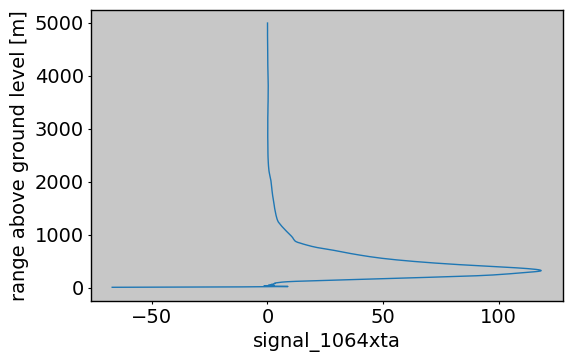

In [45]:
lidar.signal_1064xta.sel(time=slice('20220808T000000.0', '20220808T010000.0'), range=slice(0,5000)).mean('time').plot(y='range')

In [64]:
signal_an =  lidar.signal_532xpa.sel(time=slice('20220808T000000.0', '20220808T010000.0'), range=slice(500,7000)).mean('time')
signal_pc =  lidar.signal_532xpp.sel(time=slice('20220808T000000.0', '20220808T010000.0'), range=slice(500,7000)).mean('time')


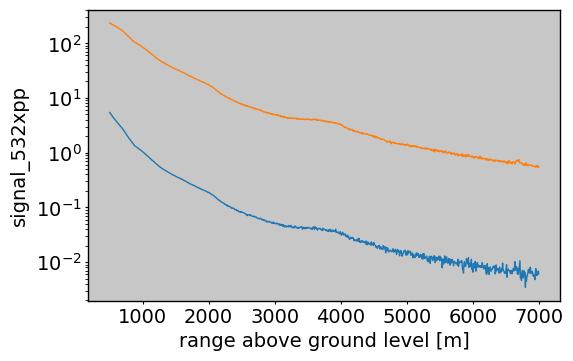

In [72]:
signal_an.plot(x='range')
signal_pc.plot(x='range')
plt.yscale('log')

Text(0, 0.5, 'PC')

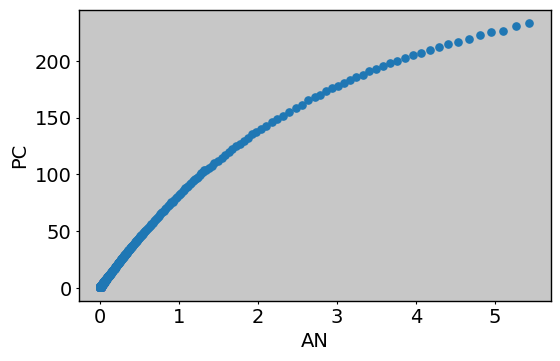

In [68]:
plt.scatter(signal_an, signal_pc)
plt.xlabel('AN')
plt.ylabel('PC')

Text(0, 0.5, 'PC')

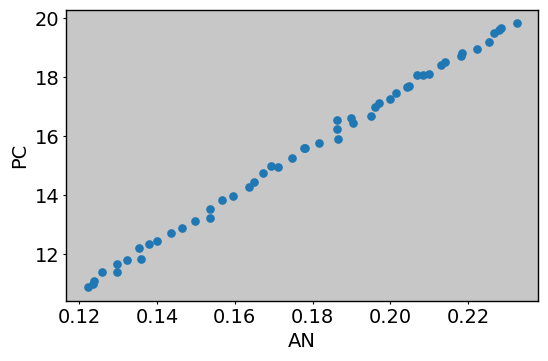

In [8]:
signal_an =  lidar.signal_532xpa.sel(time=slice('20220808T000000.0', '20220808T010000.0'), range=slice(500,3000)).mean('time')
signal_pc =  lidar.signal_532xpp.sel(time=slice('20220808T000000.0', '20220808T010000.0'), range=slice(500,3000)).mean('time')
filtering = np.logical_and(signal_an>0.122, signal_pc < 20)
plt.scatter(signal_an.where(filtering), signal_pc.where(filtering))
plt.xlabel('AN')
plt.ylabel('PC')

In [54]:
signal.shape

(666,)

In [53]:
lidar.range.shape

(2666,)

In [39]:
lidar.signal_1064xta.time

<xarray.DataArray 'time' (time: 1028)>
array(['2022-08-07T23:59:03.000000000', '2022-08-08T00:00:02.000000256',
       '2022-08-08T00:01:01.000000000', ..., '2022-08-08T23:56:10.000000000',
       '2022-08-08T23:57:09.000000000', '2022-08-08T23:58:08.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2022-08-07T23:59:03 ... 2022-08-08T23:58:08
Attributes:
    standard_name:  time